# Global Superstore Sales Analysis using Python
## Project objective
This project analyzes the Global Superstore dataset to uncover sales trends, pprofitability patterns, customer behaviour, and operational insights.
## Tools Used
Python
Pandas
Numpy
Matplotlib
seaborn


## 1. Import Libaries

In [ ]:
!pip install pandas numpy matplotlib seaborn openpyxl
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [221]:
data = pd.read_excel('Global_Superstore2.xlsx')
data.head(10)
data.tail(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51285,29002,IN-2014-62366,19-06-2014,19-06-2014,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-10000746,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,0.01,Medium
51286,35398,US-2014-102288,20-06-2014,24-06-2014,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,Texas,...,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100,0.01,Medium
51287,40470,US-2013-155768,02-12-2013,02-12-2013,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,California,...,OFF-EN-10001219,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920,3,0.0,11.2308,0.01,High
51288,9596,MX-2012-140767,18-02-2012,22-02-2012,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,São Paulo,...,OFF-BI-10000806,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,0.00,Medium
51289,6147,MX-2012-134460,22-05-2012,26-05-2012,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,...,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.380,3,0.0,1.8000,0.00,High


## 3. Initial Data Exploration

In [222]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  str    
 2   Order Date      51290 non-null  str    
 3   Ship Date       51290 non-null  str    
 4   Ship Mode       51290 non-null  str    
 5   Customer ID     51290 non-null  str    
 6   Customer Name   51290 non-null  str    
 7   Segment         51290 non-null  str    
 8   City            51290 non-null  str    
 9   State           51290 non-null  str    
 10  Country         51290 non-null  str    
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  str    
 13  Region          51290 non-null  str    
 14  Product ID      51290 non-null  str    
 15  Category        51290 non-null  str    
 16  Sub-Category    51290 non-null  str    
 17  Product Name    51290 non-null  str    
 1

## 4. Data Cleaning

### Handling Missing Values
During the data cleaning process, it was observed that the *Postal Code* column contained approximately 80.5% missing values.
Due to the high percentage of missing data, the column was dropped as it would not contribute meaningfully to the analysis 
and could negatively impact data quality.

In [223]:
data.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [224]:
count_missing = data['Postal Code'].isnull().sum()
count_total = len(data)
check_percentage = (count_missing / count_total) * 100
print(round(check_percentage, 2), '%')

80.51 %


In [225]:
if "Postal Code" in data.columns:
    data.drop(columns=['Postal Code'], inplace= True)
      

In [226]:
data.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
City              0
State             0
Country           0
Market            0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64

In [227]:
data.duplicated ().sum()

np.int64(0)

## 5. Feature Engineering

### Date Conversion and Feature Creation
The *Order Date* and *Ship Date* columns were converted to a datetime format to enable time-based analysis 
A new feature  called *shipping Delay* was created by calculating the difference between the shipping date and the order date 
which represents the number of days it took to deliver each order
After creating the *shipping Delay* feature, the column was repositioned to the 4th position in the dataset for better organisation

In [228]:

data['Order Date'] = pd.to_datetime(data['Order Date'],dayfirst=True,errors='coerce')
data['Ship Date']= pd.to_datetime(data['Ship Date'],dayfirst = True,errors = 'coerce')
print(data['Order Date'].dtype)
print(data['Ship Date'].dtype)

datetime64[us]
datetime64[us]


In [229]:
data['Shipping_Delay']= (data['Ship Date']-data['Order Date']).dt. days

In [230]:
data.head(2)
data.tail(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Shipping_Delay
51288,9596,MX-2012-140767,2012-02-18,2012-02-22,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,São Paulo,...,Office Supplies,Binders,"Acco Index Tab, Economy",13.44,2,0.0,2.4,0.0,Medium,4
51289,6147,MX-2012-134460,2012-05-22,2012-05-26,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,...,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.38,3,0.0,1.8,0.0,High,4


In [231]:
Movecolumn= list(data.columns)
Movecolumn.remove('Shipping_Delay')
Movecolumn.insert(4,'Shipping_Delay')
data = data[Movecolumn]
data.head(2)

,Row ID,Order ID,Order Date,Ship Date,Shipping_Delay,Ship Mode,Customer ID,Customer Name,Segment,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,2012-07-31,2012-07-31,0,Same Day,RH-19495,Rick Hansen,Consumer,New York City,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,2013-02-05,2013-02-07,2,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical


# 6. Exploratory Data Analysis

## Aggregate Analysis
This step involves summarizing the dataset to extract key metrics such as total sales, total  profit, 
and average discount, providing an overall view of business performance

In [232]:
Total_sales = round(data['Sales'].sum(),2)
Total_profit = round(data['Profit'].sum(),2)
Average_discount = round(data['Discount'].mean(),2)
print('The total sale is ',Total_sales)
print (' The total profit is ',Total_profit)
print ('the average discount is ',Average_discount)

The total sale is  12642501.91
 The total profit is  1467457.29
the average discount is  0.14


### Top 5 Products by Sales
This analysis identifies the top-performing products based on totalsales, helping to highlight key revenue drivers and high demand items

In [233]:
top5_products = round(data.groupby('Product Name')['Sales'].sum().sort_values(ascending = False).head(5),2)
print(top5_products)

Product Name
Apple Smart Phone, Full Size             86935.78
Cisco Smart Phone, Full Size             76441.53
Motorola Smart Phone, Full Size          73156.30
Nokia Smart Phone, Full Size             71904.56
Canon imageCLASS 2200 Advanced Copier    61599.82
Name: Sales, dtype: float64


### Highest Profit -Generating Customer
This section identifies  the custopomer contributing the highest total profit, providing insight into valuable customers
and potential reton opprtunities

In [234]:
highesttotalprofit_customer = round(data.groupby('Customer Name')['Profit'].sum().sort_values(ascending = False).head(1),2)
print(highesttotalprofit_customer)

Customer Name
Tamara Chand    8672.9
Name: Profit, dtype: float64


### Category-Level Performanc
THis analysis groups data by product category to evaluate total sales, total profit, and average qualty sold, 
offering a comprehensive view of category performance

In [235]:
grouped_data = data.groupby('Category', as_index = False).agg( Total_Sales =('Sales', 'sum'),Total_Profit = ('Profit','sum'), Average_quantity_sold = ('Quantity','mean'))
print(grouped_data)

          Category   Total_Sales  Total_Profit  Average_quantity_sold
0        Furniture  4.110874e+06  285204.72380               3.539287
1  Office Supplies  3.787070e+06  518473.83430               3.459278
2       Technology  4.744557e+06  663778.73318               3.468691


### Regional Performance Analysis
This section examines total sales and profit acreoss different regions to identify high-performing and underperforming areas

In [236]:
Region_summary = data.groupby('Region', as_index = False).agg( Total_Sales =('Sales', 'sum'),Total_Profit = ('Profit','sum'))
Region_summary=(Region_summary).round(2)
print(Region_summary)

            Region  Total_Sales  Total_Profit
0           Africa    783773.21      88871.63
1           Canada     66928.17      17817.39
2        Caribbean    324280.86      34571.32
3          Central   2822302.52     311403.98
4     Central Asia    752826.57     132480.19
5             EMEA    806161.31      43897.97
6             East    678781.24      91522.78
7            North   1248165.60     194597.95
8       North Asia    848309.78     165578.42
9          Oceania   1100184.61     120089.11
10           South   1600907.04     140355.77
11  Southeast Asia    884423.17      17852.33
12            West    725457.82     108418.45


In [237]:
region_summary = Region_summary.sort_values('Total_Profit', ascending=False)
print(region_summary)

            Region  Total_Sales  Total_Profit
3          Central   2822302.52     311403.98
7            North   1248165.60     194597.95
8       North Asia    848309.78     165578.42
10           South   1600907.04     140355.77
4     Central Asia    752826.57     132480.19
9          Oceania   1100184.61     120089.11
12            West    725457.82     108418.45
6             East    678781.24      91522.78
0           Africa    783773.21      88871.63
5             EMEA    806161.31      43897.97
2        Caribbean    324280.86      34571.32
11  Southeast Asia    884423.17      17852.33
1           Canada     66928.17      17817.39


### Most Used Shipping Mode
This analysis  explores the frequency of different shipping modes to understand customer preferences and operational trends

In [238]:
most_used_shipmode = data['Ship Mode'].value_counts().idxmax()
print(most_used_shipmode)

Standard Class


In [239]:
most_used_shipmode = data.groupby('Ship Mode').size().reset_index(name='frequency').sort_values('frequency', ascending=False)
print(most_used_shipmode)

        Ship Mode  frequency
3  Standard Class      30775
2    Second Class      10309
0     First Class       7505
1        Same Day       2701


### Critical Order Sales 
This section analyzes tottal sales from critical priority orders, providing insight into urgent demand and high-priority transaction

In [240]:
critical_sales = data[data['Order Priority']== 'Critical']
total_criticalsales =round(critical_sales['Sales'].sum(),2)
print(total_criticalsales)
total_criticalprofit = round(critical_sales['Profit'].sum(),2)
print(total_criticalprofit)

986235.46
124224.16


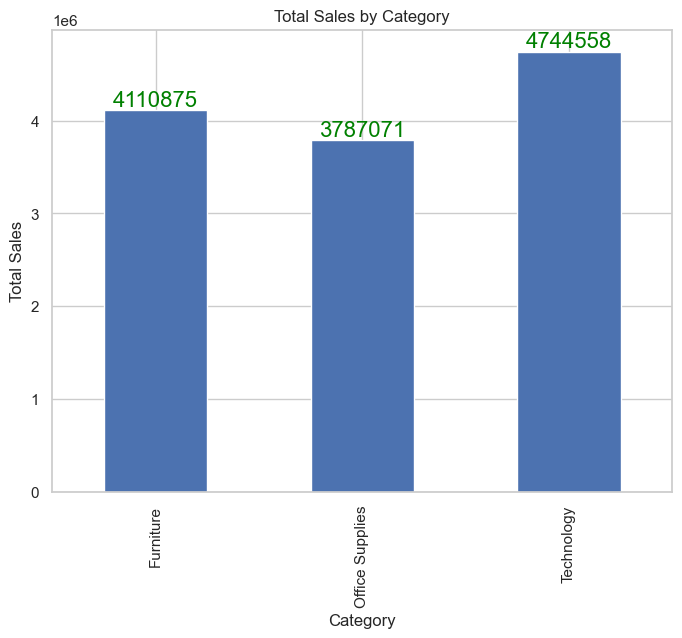

In [241]:
import matplotlib.pyplot as plt
import math
category_sales = data.groupby('Category')['Sales'].sum()
plt.figure(figsize=(8, 6))
ax = category_sales.plot(kind='bar')
for i, v in enumerate(category_sales):
    ax.text(i, math.ceil(v)+0.5, str(math.ceil(v)), ha='center', va='bottom', color='green', fontsize = 16)
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.title('Total Sales by Category')
plt.show()

Sales change frequently from day to day, with occasional peaks, but overall sales increase over time

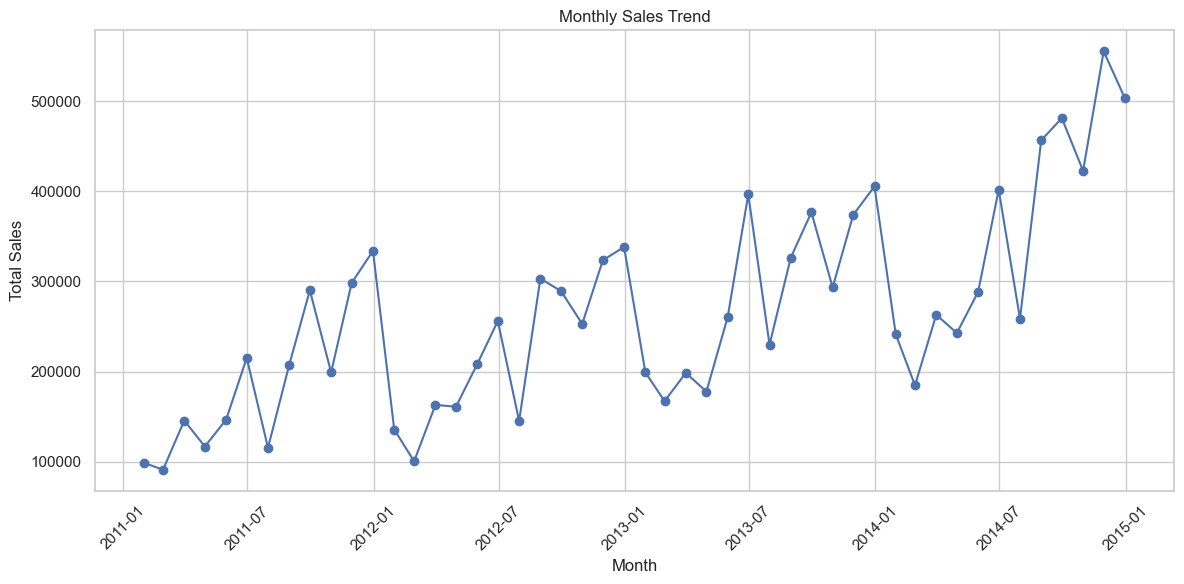

In [242]:
data.columns = data.columns.str.strip()
data['Order Date'] = pd.to_datetime(data['Order Date'])

monthly_sales = data.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# visualize profit distribution

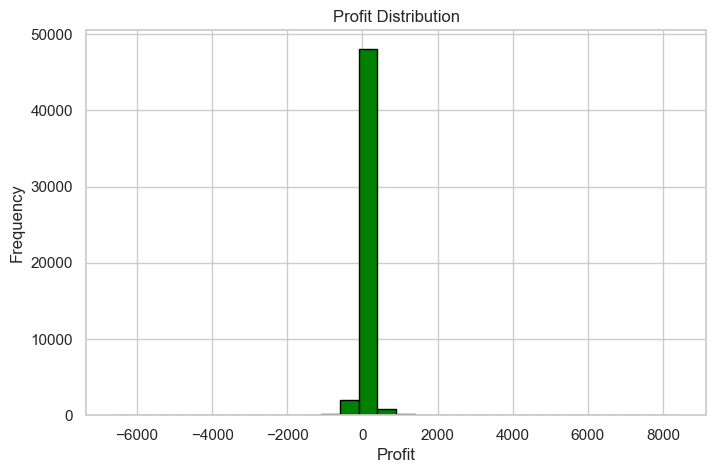

In [243]:
plt.figure(figsize=(8,5))
plt.hist(data['Profit'], bins=30, color='green', edgecolor='black')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.title('Profit Distribution')
plt.show()

Most sales generate little profit or little loss, while only a few orders result in very high profit or heavy loss

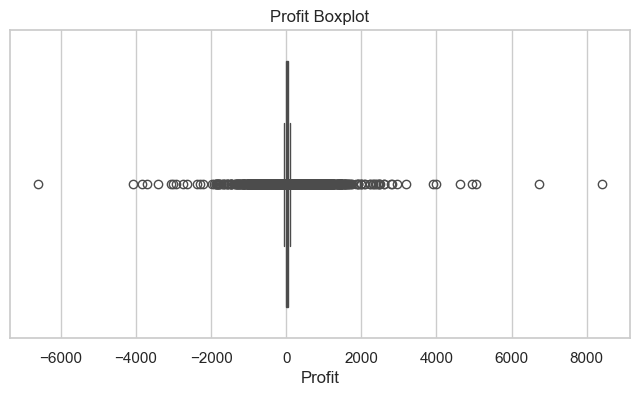

In [244]:
import seaborn as sns
plt.figure(figsize=(8,4))
sns.boxplot(x= data['Profit'])
plt.xlabel('Profit')
plt.title('Profit Boxplot')
plt.show()

Most orders across all segments generate small profits, but there are some extreme cases of very high profits and large losses. The Corporate segment shows the highest profit variability, indicating both strong gains and significant losses

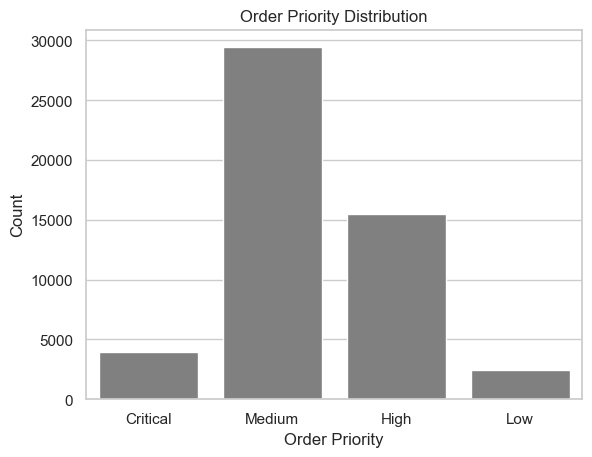

In [245]:
sns.set(style='whitegrid')
plt.figure()
sns.countplot(x='Order Priority', data=data, color='grey')
plt.xlabel('Order Priority')
plt.ylabel('Count')
plt.title('Order Priority Distribution')
plt.show()

The countplot visualizes the frequency of orders by priority level, helping identify which priorities dominate order volume and operational focus.in the graph we can see that the medium priority level dominates

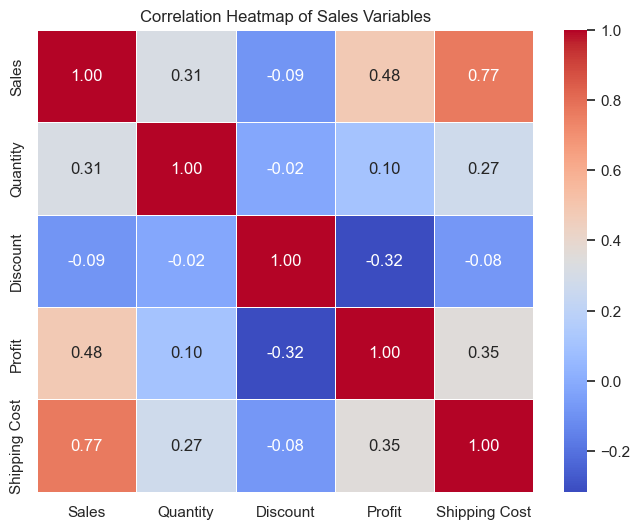

In [246]:

corr_data = data[['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost']]
corr_matrix = corr_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap( corr_matrix,annot=True, fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Heatmap of Sales Variables')
plt.show()


## 8. Key Insights

Overall Business Performance

The business recorded strong financial performance with total sales of $12.64M and total profit of $1.47M.

The average discount rate of 14% suggests a heavy reliance on price reductions to drive sales.

Product & Category Performance

Technology is the leading category, generating the highest sales ($4.74M) and profit ($663K).

Furniture, despite high sales ($4.11M), delivers relatively low profit ($285K), indicating margin inefficiencies.

Office Supplies demonstrates efficient profit conversion, making it a stable contributor.

Top-performing products are largely high-end electronics, including brands like Apple, Cisco, Motorola, and Nokia.

#### Sales Trends

Sales show a consistent upward trend (2011–2015).

However, daily fluctuations and spikes indicate inconsistent purchasing patterns or promotional impacts.

#### Profitability Drivers & Risks

There is a negative correlation (-0.32) between discount and profit, confirming that higher discounts reduce profitability.

The Corporate segment shows the highest variability—capable of both high profits and significant losses.

A single customer, Tamara Chand, is the most profitable, contributing $8,672.90.

#### Regional Performance

Top-performing regions: Central, North, and North Asia.

Underperforming regions: Canada and Southeast Asia, with very low profit contributions.

This highlights the regional imbalance in profitability.

#### Operations & Logistics

Standard Class shipping dominates, while Same Day is rarely used.

A strong positive correlation (0.77) between sales and shipping cost indicates that logistics costs grow almost proportionally with revenue.

Critical priority orders generate disproportionately high value (~$1M sales), despite lower volume.

## Strategic Recommendations
### 1. Optimize Discount Strategy

Reduce excessive discounting, especially in low-margin categories like Furniture.

Implement targeted or conditional discounts instead of blanket price reductions.

### 2. Strengthen High-Performing Categories

Increase investment in the Technology category, particularly high-performing products like smartphones and copiers.

Expand marketing and inventory for top-selling brands to maximize returns.

### 3. Improve Furniture Profitability

Review the cost structure, pricing strategy, and supply chain for Furniture.

Consider bundling or premium positioning instead of discount-heavy sales tactics.

### 4. Address Regional Gaps

Conduct a deep-dive analysis into underperforming regions like Southeast Asia and Canada.

Replicate successful strategies from the Central and North regions.

### 5. Enhance Logistics Efficiency

Negotiate better shipping contracts or optimize delivery routes.

Explore bulk shipping, warehouse optimization, or regional distribution centers to reduce costs.

### 6. Leverage High-Value Segments

Prioritize Critical priority orders, as they deliver high revenue and profit.

Develop strategies to increase the share of high-priority transactions.

### 7. Manage Customer & Segment Risk

Analyze the variability in the Corporate segment to reduce losses.

Build loyalty programs around high-value customers like top contributors.